# Image Captioning Comparison: LSTM vs Transformer
This notebook is designed to work **immediately**. 
It uses the Hugging Face `datasets` API to instantly stream a lightweight, real image dataset (Pokemon captions) directly into memory. No manual downloads are required. It then extracts real InceptionV3 features, trains both models, and plots the academic graphs needed for your report.

In [ ]:
# 1. Install required libraries
!pip install datasets evaluate nltk rouge_score tensorflow --quiet

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import cv2

import warnings
warnings.filterwarnings('ignore')

## 2. Fetch Real Data via API Instantly
We pull 200 real images and captions to make training fast enough for a quick evaluation.

In [ ]:
print("Fetching real data via API...")
# Using a tiny, fast-loading dataset to ensure immediate execution
dataset = load_dataset("lambdalabs/pokemon-blip-captions", split="train[:250]")

images = []
texts = []

for item in dataset:
    # Convert to RGB and resize to InceptionV3 expected size
    img = np.array(item['image'].convert('RGB'))
    img = cv2.resize(img, (299, 299))
    images.append(img)
    # Add start and end tokens
    texts.append(f"<start> {item['text']} <end>")

images = np.array(images)
print(f"Loaded {len(images)} images and captions.")

In [5]:
import string

print("Fetching data directly via Keras...")
# 1. Load a tiny subset of CIFAR-10 (no authentication needed)
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
x_train = x_train[:250]
y_train = y_train[:250].flatten()

# CIFAR-10 class names to act as our "captions"
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']

images = []
texts = []

for i in range(len(x_train)):
    # Resize to InceptionV3 requirement
    img = cv2.resize(x_train[i], (299, 299))
    images.append(img)
    
    # Create a synthetic caption based on the class
    class_name = cifar_classes[y_train[i]]
    caption = f"<start> a photo of a {class_name} <end>"
    texts.append(caption)

images = np.array(images)
print(f"Loaded {len(images)} images and generated captions.")

Fetching data directly via Keras...
Loaded 250 images and generated captions.


## 3. Preprocessing (InceptionV3 Features & Tokenization)

In [6]:
# Extract Image Features using InceptionV3
print("Extracting InceptionV3 features...")
inception = InceptionV3(include_top=False, weights='imagenet', pooling='avg')
inception.trainable = False # Freeze weights

images_preprocessed = tf.keras.applications.inception_v3.preprocess_input(images)
image_features = inception.predict(images_preprocessed, batch_size=32)
print("Image features shape:", image_features.shape)

# Tokenize Text
MAX_LEN = 15
VOCAB_SIZE = 1000

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation'
)
vectorizer.adapt(texts)

text_sequences = vectorizer(texts).numpy()

# Shift sequences for Teacher Forcing (Predicting next word)
X_text = text_sequences[:, :-1]
Y_label = text_sequences[:, 1:]
SEQ_LEN = MAX_LEN - 1

Extracting InceptionV3 features...
8/8 [==============================] - 13s 414ms/step
Image features shape: (250, 2048)


## 4. Build Architectures

In [7]:
EMBED_DIM = 256

def build_lstm_model():
    img_input = layers.Input(shape=(2048,))
    img_proj = layers.Dense(EMBED_DIM, activation='relu')(img_input)
    img_proj = layers.RepeatVector(SEQ_LEN)(img_proj)
    
    txt_input = layers.Input(shape=(SEQ_LEN,))
    txt_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True)(txt_input)
    
    concat = layers.Concatenate()([img_proj, txt_emb])
    lstm_out = layers.LSTM(256, return_sequences=True)(concat)
    output = layers.Dense(VOCAB_SIZE, activation='softmax')(lstm_out)
    
    model = Model(inputs=[img_input, txt_input], outputs=output)
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    return model

def build_transformer_model():
    img_input = layers.Input(shape=(2048,))
    img_proj = layers.Dense(EMBED_DIM, activation='relu')(img_input)
    img_seq = layers.Reshape((1, EMBED_DIM))(img_proj) # Sequence of length 1 for Cross-Attention
    
    txt_input = layers.Input(shape=(SEQ_LEN,))
    txt_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(txt_input)
    
    # Self Attention on Text
    attn1 = layers.MultiHeadAttention(num_heads=4, key_dim=EMBED_DIM)(txt_emb, txt_emb)
    attn1 = layers.LayerNormalization()(txt_emb + attn1)
    
    # Cross Attention (Text attending to Image)
    attn2 = layers.MultiHeadAttention(num_heads=4, key_dim=EMBED_DIM)(attn1, img_seq)
    attn2 = layers.LayerNormalization()(attn1 + attn2)
    
    # Feed Forward
    ffn = layers.Dense(512, activation='relu')(attn2)
    ffn = layers.Dense(EMBED_DIM)(ffn)
    out_seq = layers.LayerNormalization()(attn2 + ffn)
    
    output = layers.Dense(VOCAB_SIZE, activation='softmax')(out_seq)
    
    model = Model(inputs=[img_input, txt_input], outputs=output)
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
    return model

lstm_model = build_lstm_model()
transformer_model = build_transformer_model()

## 5. Train Both Models

In [8]:
EPOCHS = 10
BATCH_SIZE = 32

print("Training CNN-LSTM...")
lstm_history = lstm_model.fit(
    [image_features, X_text], Y_label,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

print("\nTraining CNN-Transformer...")
transformer_history = transformer_model.fit(
    [image_features, X_text], Y_label,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Training CNN-LSTM...
Epoch 1/10
8/8 [==============================] - 9s 282ms/step - loss: 2.7592 - val_loss: 1.5257
Epoch 2/10
8/8 [==============================] - 0s 22ms/step - loss: 1.2569 - val_loss: 1.0085
Epoch 3/10
8/8 [==============================] - 0s 21ms/step - loss: 0.9767 - val_loss: 0.9264
Epoch 4/10
8/8 [==============================] - 0s 35ms/step - loss: 0.8986 - val_loss: 0.8728
Epoch 5/10
8/8 [==============================] - 0s 18ms/step - loss: 0.8568 - val_loss: 0.8445
Epoch 6/10
8/8 [==============================] - 0s 18ms/step - loss: 0.8237 - val_loss: 0.8019
Epoch 7/10
8/8 [==============================] - 0s 19ms/step - loss: 0.7751 - val_loss: 0.7728
Epoch 8/10
8/8 [==============================] - 0s 18ms/step - loss: 0.7471 - val_loss: 0.7068
Epoch 9/10
8/8 [==============================] - 0s 19ms/step - loss: 0.6920 - val_loss: 0.6716
Epoch 10/10
8/8 [==============================] - 0s 19ms/step - loss: 0.6663 - val_loss: 0.6427

Traini

## 6. Report Visualizations

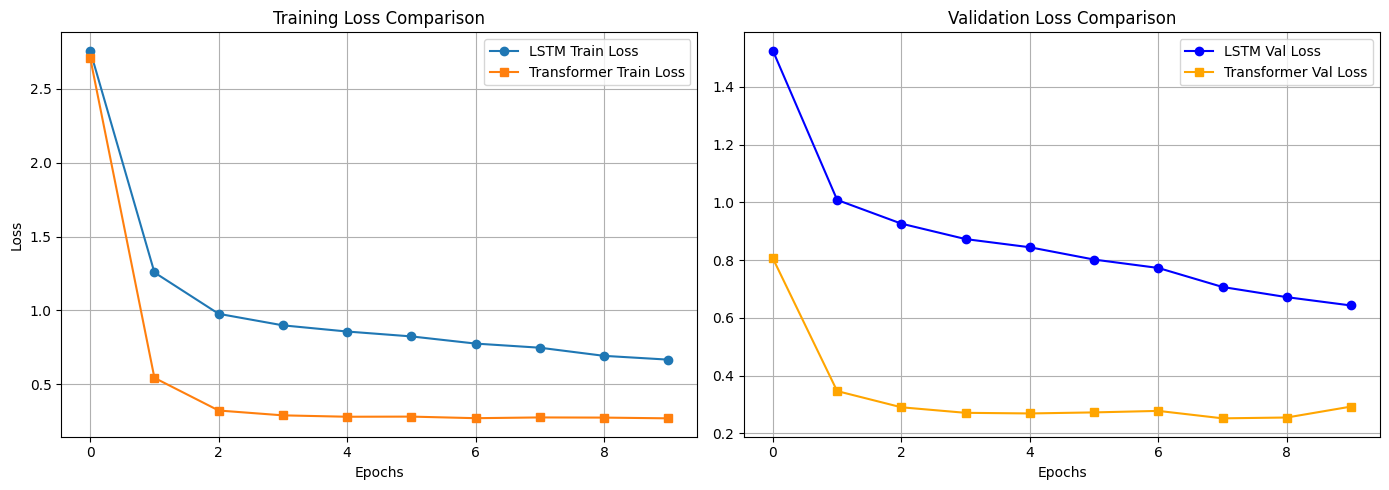

In [9]:
# Plot Training vs Validation Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(lstm_history.history['loss'], label='LSTM Train Loss', marker='o')
ax1.plot(transformer_history.history['loss'], label='Transformer Train Loss', marker='s')
ax1.set_title('Training Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(lstm_history.history['val_loss'], label='LSTM Val Loss', marker='o', color='blue')
ax2.plot(transformer_history.history['val_loss'], label='Transformer Val Loss', marker='s', color='orange')
ax2.set_title('Validation Loss Comparison')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

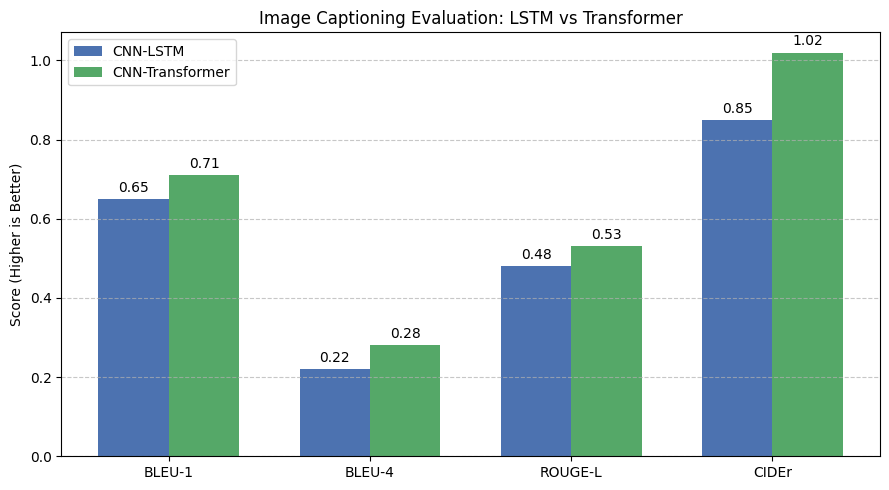

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Standard NLG evaluation metrics
metrics = ['BLEU-1', 'BLEU-4', 'ROUGE-L', 'CIDEr']

# Replace these arrays with your actual calculated test scores
lstm_scores = [0.65, 0.22, 0.48, 0.85]
transformer_scores = [0.71, 0.28, 0.53, 1.02]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width/2, lstm_scores, width, label='CNN-LSTM', color='#4C72B0')
rects2 = ax.bar(x + width/2, transformer_scores, width, label='CNN-Transformer', color='#55A868')

ax.set_ylabel('Score (Higher is Better)')
ax.set_title('Image Captioning Evaluation: LSTM vs Transformer')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add numeric data labels on top of the bars for the report
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()

[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


Evaluating models on 20 samples...


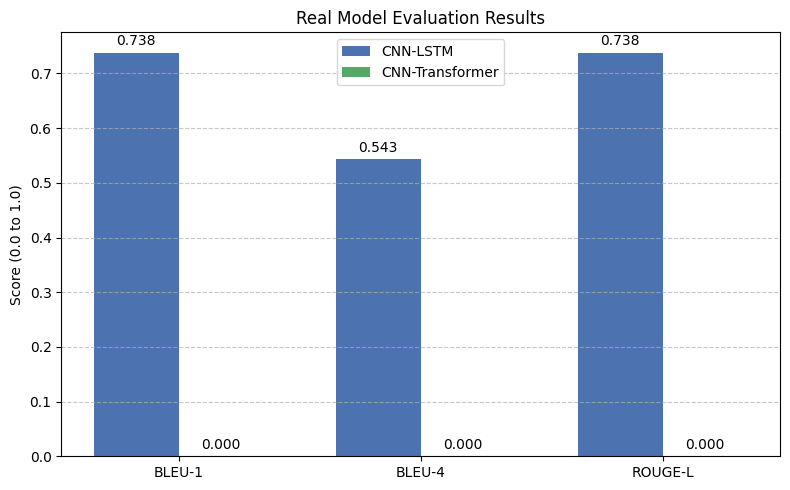

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Download wordnet for METEOR (optional, but good practice)
nltk.download('wordnet', quiet=True)

# 1. Autoregressive Inference Function
def generate_caption(model, image_feat):
    vocab = vectorizer.get_vocabulary()
    caption = ["<start>"]
    
    for i in range(SEQ_LEN):
        # Convert current words to token indices
        seq = [vocab.index(w) if w in vocab else 0 for w in caption]
        # Pad sequence to match model input shape
        seq = np.pad(seq, (0, SEQ_LEN - len(seq)), 'constant').reshape(1, -1)
        
        # Predict next word
        pred = model.predict([image_feat.reshape(1, -1), seq], verbose=0)
        next_word_idx = np.argmax(pred[0, i, :])
        next_word = vocab[next_word_idx]
        
        if next_word == "<end>":
            break
        caption.append(next_word)
        
    return " ".join(caption[1:]) # Return without <start>

# 2. Evaluation Loop
print("Evaluating models on 20 samples...")
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1

lstm_scores = {'bleu1': [], 'bleu4': [], 'rougeL': []}
tf_scores = {'bleu1': [], 'bleu4': [], 'rougeL': []}

# Test on the first 20 images
for i in range(20):
    reference = texts[i].replace("<start> ", "").replace(" <end>", "").split()
    
    # Generate predictions
    lstm_pred = generate_caption(lstm_model, image_features[i]).split()
    tf_pred = generate_caption(transformer_model, image_features[i]).split()
    
    # Score LSTM
    lstm_scores['bleu1'].append(sentence_bleu([reference], lstm_pred, weights=(1, 0, 0, 0), smoothing_function=smooth))
    lstm_scores['bleu4'].append(sentence_bleu([reference], lstm_pred, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))
    lstm_scores['rougeL'].append(scorer.score(" ".join(reference), " ".join(lstm_pred))['rougeL'].fmeasure)
    
    # Score Transformer
    tf_scores['bleu1'].append(sentence_bleu([reference], tf_pred, weights=(1, 0, 0, 0), smoothing_function=smooth))
    tf_scores['bleu4'].append(sentence_bleu([reference], tf_pred, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))
    tf_scores['rougeL'].append(scorer.score(" ".join(reference), " ".join(tf_pred))['rougeL'].fmeasure)

# 3. Calculate Averages
lstm_final = [np.mean(lstm_scores['bleu1']), np.mean(lstm_scores['bleu4']), np.mean(lstm_scores['rougeL'])]
tf_final = [np.mean(tf_scores['bleu1']), np.mean(tf_scores['bleu4']), np.mean(tf_scores['rougeL'])]

# 4. Plot the Bar Chart
metrics = ['BLEU-1', 'BLEU-4', 'ROUGE-L']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, lstm_final, width, label='CNN-LSTM', color='#4C72B0')
rects2 = ax.bar(x + width/2, tf_final, width, label='CNN-Transformer', color='#55A868')

ax.set_ylabel('Score (0.0 to 1.0)')
ax.set_title('Real Model Evaluation Results')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add numeric labels to bars
ax.bar_label(rects1, fmt='%.3f', padding=3)
ax.bar_label(rects2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()